In [76]:
## automatically reload any modules read below that might have changed (e.g. plots)
%reload_ext autoreload
%autoreload 2

In [77]:
# importing plotting and locus tools: 
import NEOfaster as nf
import NEOMOD3 as nm3  

In [78]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlopen
from io import StringIO
import numpy as np
import astropy.units as u
from astropy.time import Time
from numpy import sin, cos
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 
from astropy.coordinates import SkyCoord, get_sun, GCRS, GeocentricTrueEcliptic
import pyarrow as pa
import adam_core.coordinates
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes
from scipy.interpolate import RegularGridInterpolator

#importing the neomod3.py file for the 4D array
import NEOMOD3 as nm3

In [79]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [80]:
obstime_str="2025-09-23T00:00:00"
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 186.35, -5.0, 46.27, -19.0
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22 
# add mag here
mag = 20.0
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0


In [81]:

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 
neo_score, a, e, i = nf.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)

neo_score: 0.40217
a: 1.8147948989466378
e: 0.358504361404317
i: 26.36952675502365


In [85]:
def comp_sum():
    
    N_rate = 31           #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    dra_vals  = np.linspace(-0.6, 0.6, N_rate)
    ddec_vals = np.linspace(-0.6, 0.6, N_rate)
    
    
    
    H = np.zeros((len(dra_vals), len(ddec_vals)), dtype=float)
    
    for i,dra in enumerate(dra_vals):
        for j,ddec in enumerate(ddec_vals):
            vlam, vbet = nf.radec_rates_to_ecliptic_rates1(ra0_deg, dec0_deg, dra, ddec)
            w_int = nf.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                        ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                        )
            

            H[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [dra_vals[0], dra_vals[-1], ddec_vals[0], ddec_vals[-1]]
    return H, extent

H, extent= comp_sum()


In [87]:
def comp_sum1():
    
    N_rate = 31           #2 mins 30 sec, for 31 = 4 mins 20 sec so around 50 mins for 101 --> 1 min 40 s for 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6

    vlam_vals  = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    vlam_deg_day = 0.12
    vbeta_deg_day = 0.22
    

    
    
    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)
    
    for i,vlam in enumerate(vlam_vals):
        for j,vbet in enumerate(vbet_vals):
            dra, ddec = nf. ecliptic_rates_to_radec_rates(ra0_deg, dec0_deg, vlam, vbet)
            w_int = nf.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                        ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                        )
            

            K[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent

K, extent= comp_sum1()



/tmp/ipykernel_219405/3141553312.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


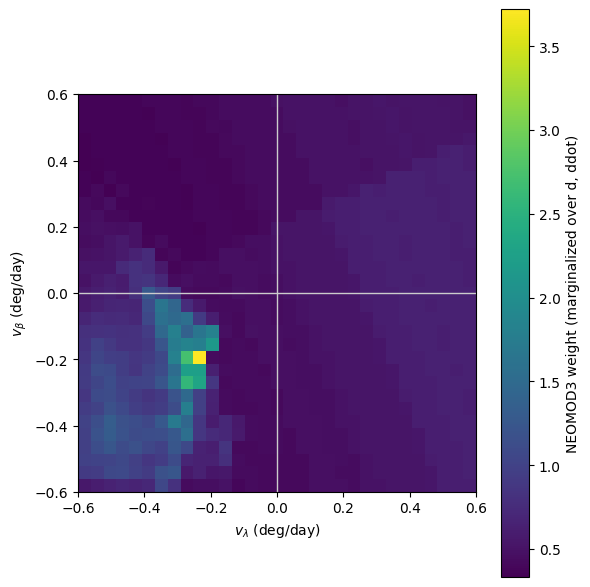

In [86]:
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(H, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()




/tmp/ipykernel_219405/3546784570.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")


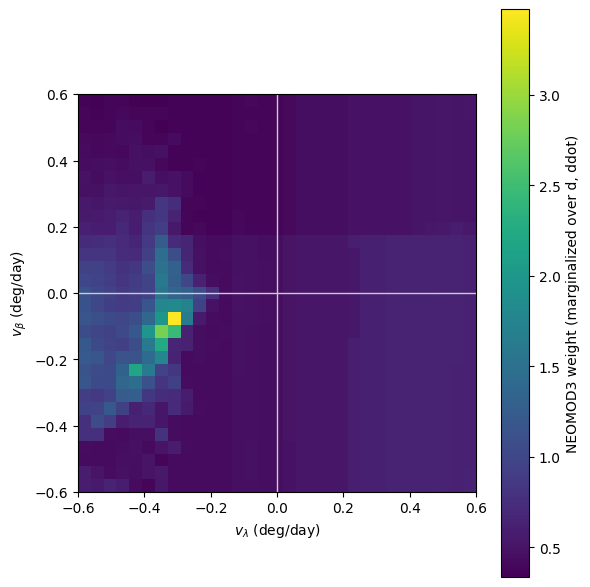

In [89]:
# VERSION WITH FLIPPED DRA VLAMBDA
from matplotlib import cm
plt.figure(figsize=(6.0, 6.0))
 
my_viridis = cm.get_cmap("viridis", 1024).with_extremes(under="white")
im = plt.imshow(K, origin="lower", extent=extent, cmap=my_viridis, aspect="equal")


plt.colorbar(label="NEOMOD3 weight (marginalized over d, ddot)")

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.tight_layout()
plt.show()



In [35]:
from IPython.display import HTML
from pyinstrument import Profiler
profiler = Profiler()
profiler.start()

nf.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                        ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,
                                                        H0=19.0, i0=25.9, obstime_str=obstime_str)

profiler.stop()
profiler.print()
with open("profile_report.html", "w") as f:
    f.write(profiler.output_html())


  _     ._   __/__   _ _  _  _ _/_   Recorded: 12:18:48  Samples:  160
 /_//_/// /_\ / //_// / //_'/ //     Duration: 0.160     CPU time: 0.171
/   _/                      v5.1.1

Profile at /tmp/ipykernel_219405/3116584518.py:4

0.160 <module>  /tmp/ipykernel_219405/3116584518.py:1
└─ 0.160 weight_marginalized_over_d_and_ddot  NEOfaster.py:70
   ├─ 0.154 compute_neomod3_weight  NEOfaster.py:239
   │  ├─ 0.151 to_keplerian_adam  NEOfaster.py:166
   │  │  ├─ 0.085 CartesianCoordinates.to_keplerian  adam_core/coordinates/cartesian.py:371
   │  │  │  └─ 0.085 KeplerianCoordinates.from_cartesian  adam_core/coordinates/keplerian.py:250
   │  │  │     ├─ 0.032 cartesian_to_keplerian  adam_core/coordinates/transform.py:547
   │  │  │     │  ├─ 0.015 process_in_chunks  adam_core/utils/chunking.py:26
   │  │  │     │  │  └─ 0.015 pad_to_fixed_size  adam_core/utils/chunking.py:4
   │  │  │     │  │     └─ 0.013 pad  numpy/lib/_arraypad_impl.py:545
   │  │  │     │  │           [7 frames hidden]